# My Tools 

In [56]:
def add_vertex_monomials(G,method='default'):
    if method=='alpha' and G.order() <= 10:
        monomials_default=['a','b','c','d','e','f','g','h','i','j','k']
        monomials=monomials_default[:G.order()]
    else:
        monomials=['a%s' %(i) for i in range(G.order())]
    V=PolynomialRing(ZZ,names=monomials,order='invlex')
    V.inject_variables()
    if G.is_directed():
        H = DiGraph()
    else:
        H = Graph()
    for v in G.vertices():
        H.add_vertex(V.gen(v))
    for e in G.edges():
        if e[0]<e[1]:
            H.add_edge(V.gen(e[0]),V.gen(e[1]),e[2])
            if G.is_directed():
                H.add_edge(V.gen(e[1]),V.gen(e[0]),e[2])   
    return H

In [57]:
def add_edge_monomials(G,method='default',edge_vars=['a','b','c','d','e','f','g','h','i','j','k']):
    #V=G.vertices()
    #if method=='default' and V[0]==0: # e01, ... need vertices to be integers here 
    if method=='default': # e01, ... need vertices to be integers here 
        E=PolynomialRing(ZZ,G.order(),G.order(),var_array=['e'],order='invlex')
        E.inject_variables()
        for e in G.edges():
            if e[0]<e[1]:
                G.add_edge(e[0],e[1],E.gen(G.order()*e[0]+e[1]))
                if G.is_directed():
                    G.add_edge(e[1],e[0],E.gen(G.order()*e[1]+e[0]))  
    else:
        if G.is_directed():
            edge_vars = edge_vars[:G.size()/2]
            edge_vars_bar = [ ev+'bar' for ev in edge_vars ] 
            E=PolynomialRing(ZZ,names=edge_vars+edge_vars_bar,order='invlex')
            E.inject_variables()
            evars = list(E.gens()[:G.size()/2])
            evars.reverse()
            evars_bar = list(E.gens()[G.size()/2:])   
            evars_bar.reverse()
            for e in G.edges():
                if e[0]<e[1]:
                    G.add_edge(e[0],e[1],evars.pop())
                    G.add_edge(e[1],e[0],evars_bar.pop())
        else:
            edge_vars = edge_vars[:G.size()]
            E=PolynomialRing(ZZ,names=edge_vars,order='invlex')
            E.inject_variables()
            evars = list(E.gens()[:G.order()])
            evars.reverse()
            for e in G.edges():
                if e[0]<e[1]:
                    G.add_edge(e[0],e[1],evars.pop())
    return G

In [58]:
def my_laplacian_matrix_old(G):
    A=matrix(SR,G.order())
    V=G.vertices()
    for i in range(G.order()):
        for j in range(G.order()):
            if G.has_edge(V[i],V[j]):
                A[i,j]=G.edge_label(V[i],V[j])
    L=diagonal_matrix(sum(A))-A
    return L

In [59]:
def combinatorial_laplacian(G,combinatorial_coefficients=False):
    v=G.vertices()
    A = matrix(SR, G.order(), lambda i,j: G.edge_label(v[i],v[j]) if G.has_edge(v[i],v[j]) else 0)
    if combinatorial_coefficients:
        for i in range(G.order()):
            for j in range(G.order()):
                if G.has_edge(v[i],v[j]):
                    A[i,j]=combinatorial_coefficient(v[i],v[j])*A[i,j]
    D = diagonal_matrix(sum(A.transpose()))
    L=D-A
    return L

In [60]:
def tree_polynomial(G,root=1,combinatorial_coefficients=False):
    L=combinatorial_laplacian(G,combinatorial_coefficients)
    I=list(range(L.nrows()))
    I.remove(root)
    T=det(L[I,I]).expand()
    return T

In [61]:
def coefficient_transition_context_from_reduced_graph_power(G,f,g):
    #if not G.has_edge(f,g):
    #    print('***',f,g)
    #    return None, None, None, None 
    #else:
    V=G.vertices()
    elabel=G.edge_label(f,g)
    coeff=elabel[0]
    fr=elabel[1][0]
    to=elabel[1][1]
    context=elabel[2]
    return coeff, (fr,to), context

In [62]:
def coefficient_transition_context_from_tuple(from_tuple,to_tuple):
    if len(from_tuple)!=len(to_tuple):
        raise ValueError('Tuples must be the same size.')
    d=list(vector(to_tuple)-vector(from_tuple))
    fr=d.index(-1)
    to=d.index(1)
    coeff=from_tuple[fr]
    context=list(from_tuple) 
    context[fr]=context[fr]-1
    return coeff, (fr,to), context 
    

In [63]:
def Cartesian_power(G, k):
    # Make Cartesian power G^k (unreduced)
    Gk=G
    for i in range(k-1):
        Gk = Gk.cartesian_product(G)
    # Make each vertex a tuple
    vflat=list([0]*Gk.order())
    for i in range(Gk.order()):
        v=Gk.vertices()[i]
        vflat[i]=tuple(flatten(v))
    Gk.relabel(vflat)
    return Gk

In [64]:
def reduced_Cartesian_power(G, k):
    V=G.vertices()
    if V[0]!=0: # construct reduced Cartesian power using monomials
        f=1
        for kk in range(k):
            f=f*sum(G.vertices())
        fmon = f.monomials()
        fmon.reverse()
        if G.is_directed():
            Gk = DiGraph()
        else: 
            Gk = Graph()
        for fi in fmon: 
            for fj in fmon:
                df=fj/fi
                aj=df.numerator()
                ai=df.denominator()
                if G.has_edge(ai,aj):
                    coeff=fi.degree(ai)
                    if G.edge_label(ai,aj):
                        Gk.add_edge(fi,fj,(coeff,G.edge_label(ai,aj),fj.gcd(fi)))
                    else:
                        Gk.add_edge(fi,fj,(coeff,(ai,aj),fj.gcd(fi)))
                        #print(fi,fj,(ai,aj),fj.gcd(fi))
    else: # construct reduced Cartesian power using tuples of integers 
        Gk = Cartesian_power(G,k) # reduced 
        for v in Gk.vertices(): # do reduction by merging vertices  
            for u in Gk.vertices():
                sv=tuple(sorted(v))
                su=tuple(sorted(u))
                if v!=u and sv==su and v<u and Gk.has_vertex(v) and Gk.has_vertex(u):
                    Gk.merge_vertices([v,u])
        vcount=[0]*Gk.order()
        for i in range(Gk.order()):
            vc=[0]*G.order() # yes, G, not Gk, the number of vertices in monomial model 
            for x in Gk.vertices()[i]:
                vc[x]=vc[x]+1
            vcount[i]=tuple(vc) 
        Gk.relabel(vcount)
        for e in Gk.edges():
            #print(e[0],e[1],coefficient_transition_context_from_tuple(e[0],e[1]))
            Gk.set_edge_label(e[0],e[1],coefficient_transition_context_from_tuple(e[0],e[1]))
    return Gk

# Examples of using these tools on `monomial` receptor models 

Variables from a polynomial ring added as edge labels.  The default is show below.

Defining e00, e01, e02, e03, e10, e11, e12, e13, e20, e21, e22, e23, e30, e31, e32, e33


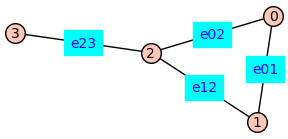

[(0, 1, e01), (0, 2, e02), (1, 2, e12), (2, 3, e23)]

In [65]:
import sage.graphs.graph_plot
sage.graphs.graph_plot.DEFAULT_SHOW_OPTIONS['figsize'] = [3,3]
sage.graphs.graph_plot.DEFAULT_SHOW_OPTIONS['transparent'] = true

G=graphs.CycleGraph(3)
G.add_edge(2,3)
G=add_edge_monomials(G)
G.show(edge_labels=true,layout='spring',edge_labels_background='cyan')
G.edges()

Variables from a polynomial ring added as edge labels.  Use method='alpha' fir easy-to-read variables.

Defining a, b, c, d


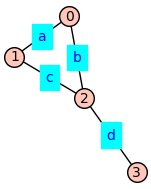

[(0, 1, a), (0, 2, b), (1, 2, c), (2, 3, d)]

In [66]:
G=add_edge_monomials(G,method='alpha')
G.show(figsize=3,edge_labels=true,layout='spring',edge_labels_background='cyan')
G.edges()

The `combinatorial_lapacian(G)` function returns the Laplacian with the variables that label edges of graph `G`.

In [67]:
L=combinatorial_laplacian(G); L

[    a + b        -a        -b         0]
[       -a     a + c        -c         0]
[       -b        -c b + c + d        -d]
[        0         0        -d         d]

Similarly for the `tree_polynomial(G)` function.

In [68]:
T=tree_polynomial(G); T

a*b*d + a*c*d + b*c*d

Here I create a directed graph with default edge monomials and another with easy-to-read edge monomials.

Defining e00, e01, e02, e03, e10, e11, e12, e13, e20, e21, e22, e23, e30, e31, e32, e33


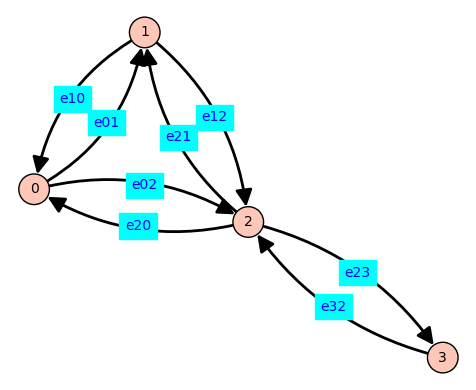

[(0, 1, e01), (0, 2, e02), (1, 0, e10), (1, 2, e12), (2, 0, e20), (2, 1, e21), (2, 3, e23), (3, 2, e32)]
Defining a, b, c, d, abar, bbar, cbar, dbar


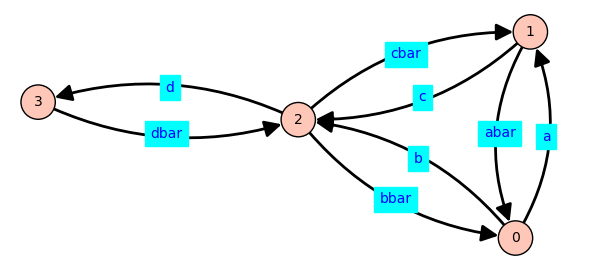

[(0, 1, a), (0, 2, b), (1, 0, abar), (1, 2, c), (2, 0, bbar), (2, 1, cbar), (2, 3, d), (3, 2, dbar)]


In [69]:
D=graphs.CycleGraph(3) 
D.add_edge(2,3)
D=D.to_directed()
D1=add_edge_monomials(D)
D1.show(figsize=6,edge_labels=true,layout='spring',edge_labels_background='cyan')
print(D1.edges())
D2=add_edge_monomials(D,method='alpha')
D2.show(figsize=6,edge_labels=true,layout='spring',edge_labels_background='cyan')
print(D2.edges())

The combinatorial laplacian and tree polynomial using labeled arcs of symmetric directed graph $D_2$.

In [70]:
print(combinatorial_laplacian(D2),'\n'*2,tree_polynomial(D2)) 

[          a + b              -a              -b               0]
[          -abar        abar + c              -c               0]
[          -bbar           -cbar bbar + cbar + d              -d]
[              0               0           -dbar            dbar] 

 a*bbar*dbar + a*cbar*dbar + b*cbar*dbar


# Examples of `dimer` and `higher-order oligomer` receptor models.

The undirected reduced graph power $C_3^{(2)}$:

Defining a0, a1, a2


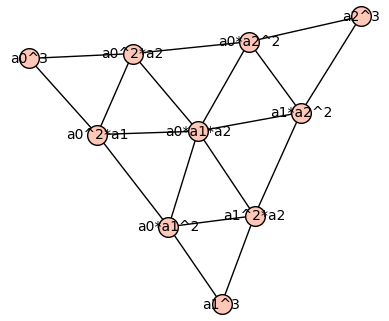

In [71]:
G=graphs.CycleGraph(3)
G=add_vertex_monomials(G)
Gk = reduced_Cartesian_power(G, 3)
Gk.show(figsize=5)

The symmetric directed version of $C_3^{(2)}$.  Each edge label is a 3-tuple: (coefficient, (origin, destination), context)

Defining a0, a1, a2


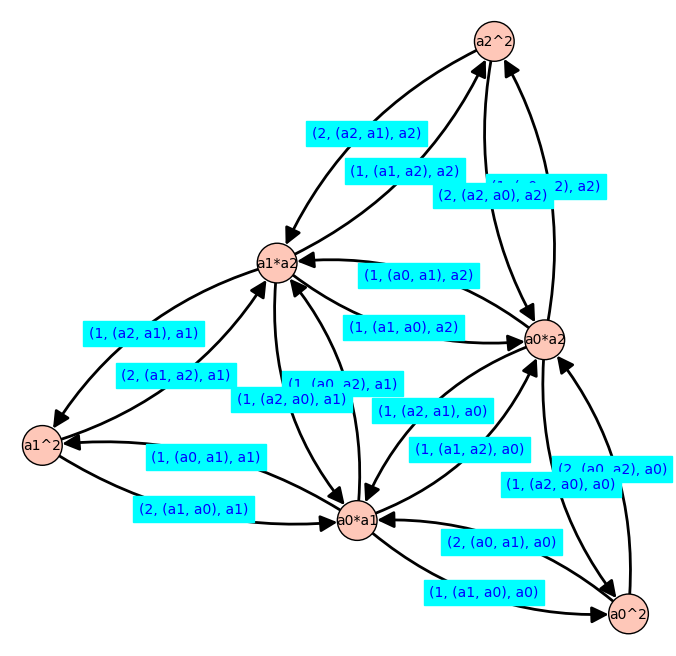

In [72]:
D=graphs.CycleGraph(3) 
D=D.to_directed()
D=add_vertex_monomials(D)
Dk = reduced_Cartesian_power(D, 2)
Dk.show(figsize=10,edge_labels=true,edge_labels_background='cyan')

The symmetric directed version of $C_5^{(3)}$.  The `coefficient_transition_context_from_reduced_graph_power` function retrieves information about edge labels even though they are not plotted.

In [73]:
D=graphs.CycleGraph(5) 
D=D.to_directed()
D=add_vertex_monomials(D)
Dk = reduced_Cartesian_power(D, 3)
vk1=0
vk2=0
while not Dk.has_edge(vk1,vk2):
    vk1=Dk.random_vertex()
    vk2=Dk.random_vertex()
print(vk1,vk2,coefficient_transition_context_from_reduced_graph_power(Dk,vk1,vk2))

Defining a0, a1, a2, a3, a4
a0*a1*a3 a0*a2*a3 (1, (a1, a2), a0*a3)


The symmetric directed version of the `unreduced` Cartesian power $P_n^{k}$.  By default, the vertex labels are $k$-tuples, each element of which is the state $(0, 1, \ldots, n-1)$ of one of the $k$ monomers.

In [74]:
n=5
k=3
Gk = Cartesian_power(graphs.PathGraph(5), 3)
print(Gk.vertices())

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 0, 4), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 1, 4), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (1, 2, 4), (1, 3, 0), (1, 3, 1), (1, 3, 2), (1, 3, 3), (1, 3, 4), (1, 4, 0), (1, 4, 1), (1, 4, 2), (1, 4, 3), (1, 4, 4), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 0, 4), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 1, 4), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (2, 2, 4), (2, 3, 0), (2, 3, 1), (2, 3, 2), (2, 3, 3), (2, 3, 4), (2, 4, 0), (2, 4, 1), (2, 4, 2), (2, 4, 3), (2, 4, 4), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 0, 4), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 1, 4), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3), (3, 2, 4), (3, 3, 0)

When the Cartesian power $P_n^{k}$ is `reduced` to $P_n^{(k)}$, the vertex labels are $n$-tuples, the $i$-th element of which is the number of monomers in the $i$-th state (a value from $0$ to $k$).   

In [75]:
Gk = reduced_Cartesian_power(graphs.PathGraph(n), k)
print(Gk.vertices())

[(0, 0, 0, 0, 3), (0, 0, 0, 1, 2), (0, 0, 0, 2, 1), (0, 0, 0, 3, 0), (0, 0, 1, 0, 2), (0, 0, 1, 1, 1), (0, 0, 1, 2, 0), (0, 0, 2, 0, 1), (0, 0, 2, 1, 0), (0, 0, 3, 0, 0), (0, 1, 0, 0, 2), (0, 1, 0, 1, 1), (0, 1, 0, 2, 0), (0, 1, 1, 0, 1), (0, 1, 1, 1, 0), (0, 1, 2, 0, 0), (0, 2, 0, 0, 1), (0, 2, 0, 1, 0), (0, 2, 1, 0, 0), (0, 3, 0, 0, 0), (1, 0, 0, 0, 2), (1, 0, 0, 1, 1), (1, 0, 0, 2, 0), (1, 0, 1, 0, 1), (1, 0, 1, 1, 0), (1, 0, 2, 0, 0), (1, 1, 0, 0, 1), (1, 1, 0, 1, 0), (1, 1, 1, 0, 0), (1, 2, 0, 0, 0), (2, 0, 0, 0, 1), (2, 0, 0, 1, 0), (2, 0, 1, 0, 0), (2, 1, 0, 0, 0), (3, 0, 0, 0, 0)]


Here I use $C_5^{(3)}$ and return the coefficient, transition and context for a randomly selected edge.

In [76]:
D=graphs.CycleGraph(5) 
D=D.to_directed()
Dk = reduced_Cartesian_power(D, 2)
ek = Dk.random_edge()
print('Transition', ek[0], 'to', ek[1], 'has')
print('has coefficient, transition, and context:')
print(coefficient_transition_context_from_reduced_graph_power(Dk,ek[0],ek[1]))

Transition (0, 0, 0, 1, 1) to (0, 0, 0, 2, 0) has
has coefficient, transition, and context:
(1, (4, 3), [0, 0, 0, 1, 0])


In [77]:
coefficient_transition_context_from_tuple((0,3,0),(1,2,0))

(3, (1, 0), [0, 2, 0])

In [78]:
print('These two function ought to return the same tuples:',\
coefficient_transition_context_from_reduced_graph_power(Dk,ek[0],ek[1])==coefficient_transition_context_from_tuple(ek[0],ek[1]))

These two function ought to return the same tuples: True


# `Spanning trees` of receptor oligomers and `contexts` of transitions on monomer model

In [79]:
def my_random_spanning_tree(G,show=True,color='red'):
    if G.is_directed():
        print('Not yet')
    else:
        T=G.random_spanning_tree()
        if show:
            G.show(figsize=3,vertex_labels=false,vertex_size=20,edge_colors={color : T })
    return T

Defining a0, a1, a2, a3


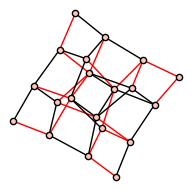

[(a0^3, a0^2*a3), (a0^2*a3, a0^2*a2), (a0^2*a2, a0^2*a1), (a0^2*a1, a0*a1*a3), (a0*a1*a3, a1*a3^2), (a1*a3^2, a1*a2*a3), (a1*a2*a3, a0*a2*a3), (a0*a2*a3, a0*a3^2), (a0^2*a2, a0*a1*a2), (a0*a1*a2, a1^2*a2), (a1^2*a2, a1^2*a3), (a1*a2*a3, a2^2*a3), (a1*a2*a3, a1*a2^2), (a2^2*a3, a2^3), (a1^2*a2, a1^3), (a1^3, a0*a1^2), (a0*a1*a2, a0*a2^2), (a0*a2*a3, a2*a3^2), (a0*a3^2, a3^3)]


In [80]:
Gk=reduced_Cartesian_power(add_vertex_monomials(graphs.CycleGraph(4)),3)
Tk=my_random_spanning_tree(Gk)
print(Tk)

[(a0, a1, a1^2), (a0, a1, a0*a2), (a0, a1, a1*a2), (a0, a1, a2*a3), (a0, a3, a0^2), (a0, a3, a0*a1), (a0, a3, a1*a3), (a0, a3, a2*a3), (a0, a3, a3^2), (a1, a2, a0^2), (a1, a2, a1^2), (a1, a2, a0*a2), (a1, a2, a2*a3), (a2, a3, a0^2), (a2, a3, a1^2), (a2, a3, a1*a2), (a2, a3, a2^2), (a2, a3, a0*a3), (a2, a3, a1*a3)]


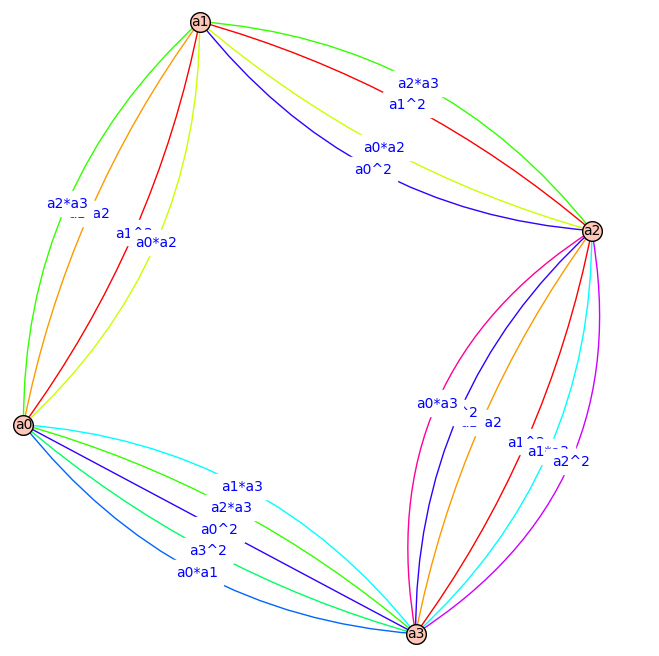

In [81]:
G.delete_edges(G.edges())
G.allow_multiple_edges(new=true)
for ek in Tk:
    coeff, transition, context = coefficient_transition_context_from_reduced_graph_power(Gk,ek[0],ek[1])
    G.add_edge(transition[0],transition[1],context)
print(G.edges())    
G.show(figsize=10,edge_labels=true,color_by_label=true)

Defining a0, a1, a2, a3

 [(a0*a1, a1*a3, (1, (a0, a3), a1)), (a1^2, a0*a1, (2, (a1, a0), a1)), (a0*a2, a0*a1, (1, (a2, a1), a0)), (a1*a2, a2^2, (1, (a1, a2), a2)), (a2^2, a2*a3, (2, (a2, a3), a2)), (a0*a3, a0^2, (1, (a3, a0), a0)), (a1*a3, a1*a2, (1, (a3, a2), a1)), (a2*a3, a3^2, (1, (a2, a3), a3)), (a3^2, a0*a3, (2, (a3, a0), a3))]


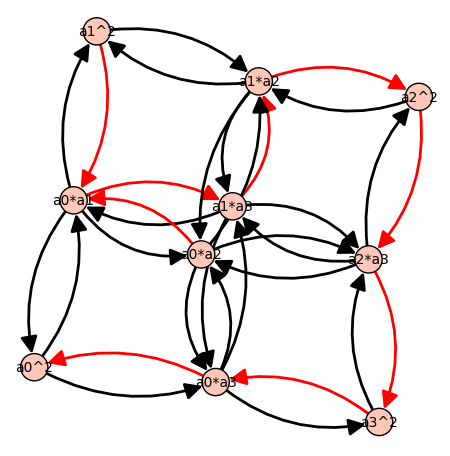

[(a0, a3, a1), (a1, a0, a1), (a1, a2, a2), (a2, a1, a0), (a2, a3, a2), (a2, a3, a3), (a3, a0, a0), (a3, a0, a3), (a3, a2, a1)]


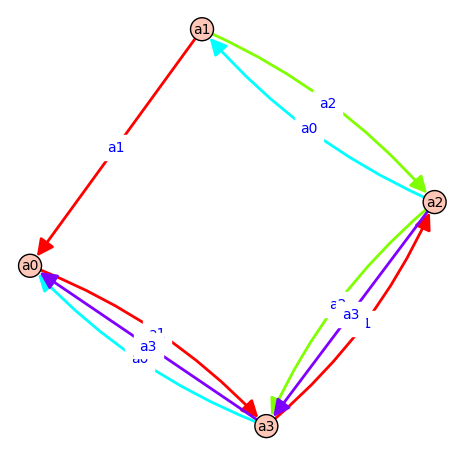


 [(a0*a1, a1*a3, (1, (a0, a3), a1)), (a1^2, a0*a1, (2, (a1, a0), a1)), (a0*a2, a1*a2, (1, (a0, a1), a2)), (a1*a2, a2^2, (1, (a1, a2), a2)), (a2^2, a2*a3, (2, (a2, a3), a2)), (a0*a3, a0^2, (1, (a3, a0), a0)), (a1*a3, a1*a2, (1, (a3, a2), a1)), (a2*a3, a3^2, (1, (a2, a3), a3)), (a3^2, a0*a3, (2, (a3, a0), a3))]


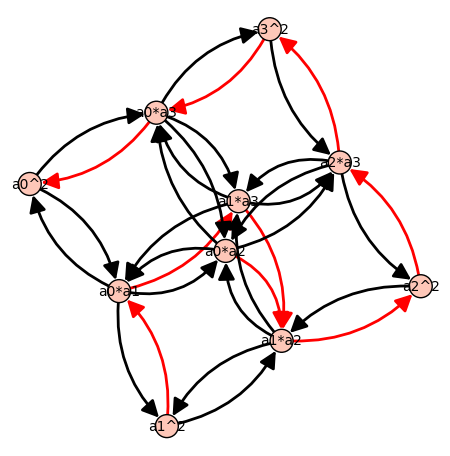

[(a0, a1, a2), (a0, a3, a1), (a1, a0, a1), (a1, a2, a2), (a2, a3, a2), (a2, a3, a3), (a3, a0, a0), (a3, a0, a3), (a3, a2, a1)]


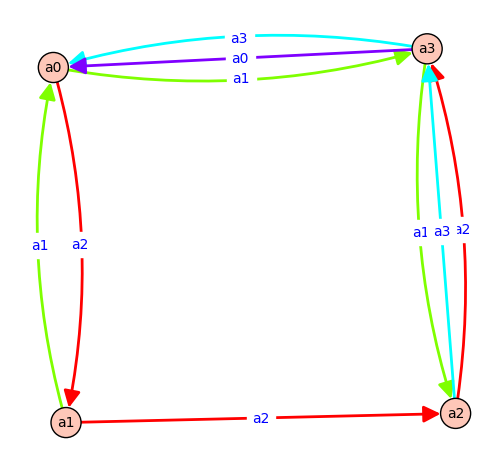


 [(a0*a1, a0*a2, (1, (a1, a2), a0)), (a1^2, a0*a1, (2, (a1, a0), a1)), (a0*a2, a1*a2, (1, (a0, a1), a2)), (a1*a2, a2^2, (1, (a1, a2), a2)), (a2^2, a2*a3, (2, (a2, a3), a2)), (a0*a3, a0^2, (1, (a3, a0), a0)), (a1*a3, a0*a1, (1, (a3, a0), a1)), (a2*a3, a3^2, (1, (a2, a3), a3)), (a3^2, a0*a3, (2, (a3, a0), a3))]


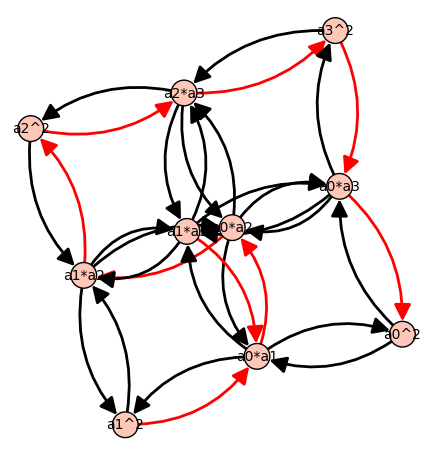

[(a0, a1, a2), (a1, a0, a1), (a1, a2, a0), (a1, a2, a2), (a2, a3, a2), (a2, a3, a3), (a3, a0, a0), (a3, a0, a1), (a3, a0, a3)]


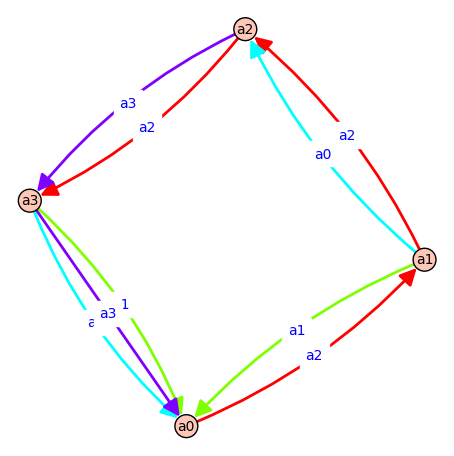


 [(a0*a1, a0*a2, (1, (a1, a2), a0)), (a1^2, a0*a1, (2, (a1, a0), a1)), (a0*a2, a1*a2, (1, (a0, a1), a2)), (a1*a2, a2^2, (1, (a1, a2), a2)), (a2^2, a2*a3, (2, (a2, a3), a2)), (a0*a3, a0^2, (1, (a3, a0), a0)), (a1*a3, a1*a2, (1, (a3, a2), a1)), (a2*a3, a3^2, (1, (a2, a3), a3)), (a3^2, a0*a3, (2, (a3, a0), a3))]


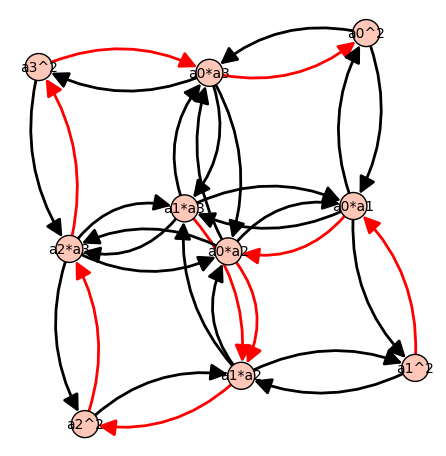

[(a0, a1, a2), (a1, a0, a1), (a1, a2, a0), (a1, a2, a2), (a2, a3, a2), (a2, a3, a3), (a3, a0, a0), (a3, a0, a3), (a3, a2, a1)]


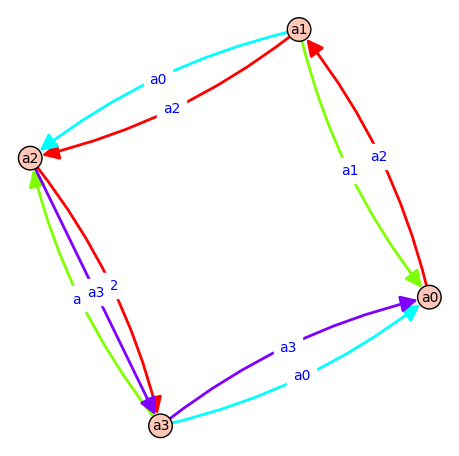

In [85]:
D=add_vertex_monomials(graphs.CycleGraph(4)).to_directed()
Dk = reduced_Cartesian_power(D, 2)
root_index=0
for Tk in list(Dk.in_branchings(Dk.vertices()[root_index],spanning=True))[0:4]:
    D.delete_edges(D.edges())
    D.allow_multiple_edges(new=true)
    for ek in Tk.edges():
        coeff, transition, context = coefficient_transition_context_from_reduced_graph_power(Tk,ek[0],ek[1])
        D.add_edge(transition[0],transition[1],context)
    print('\n',Tk.edges())
    Dk.show(figsize=7,edge_colors={'red' : Tk.edges() },layout='spring')
    print(D.edges())
    D.show(figsize=7,edge_labels=true,color_by_label=true)